# Reflection + Evaluator-Optimizer

Agent가 자기 출력을 검토하고 개선하는 패턴을 배운다.

In [1]:
from operator import add
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field


load_dotenv()

MODEL_NAME = "gemini-3.6-flash"

### Reflection 패턴

가장 단순한 자기 개선 루프다.

```
START → generate → should_continue? → END (종료)
          ↑                │ continue
          └──── reflect ←──┘
```

동작 순서:

1. **generate** 노드가 초안을 작성한다
2. **should_continue**가 반복 횟수를 체크한다 — 상한에 도달하면 최종 초안을 남기고 종료한다
3. 종료 전이면 **reflect** 노드가 초안을 읽고 피드백을 준다 (톤, 빠진 정보, 길이 등)
4. 피드백을 반영해 다시 generate로 돌아간다

State에 `messages`를 누적하므로 generate 노드는 이전 피드백을 자연스럽게 참고한다.

### Reflection 실습

시나리오: 고객에게 보내는 사과 이메일 초안을 작성하고, 반복적으로 개선한다.

In [2]:
class ReflectionState(TypedDict):
    messages: Annotated[list, add_messages]
    iteration: int


MAX_ITERATIONS = 3
generator_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)
reviewer_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

In [3]:
def generate(state: ReflectionState):
    """초안을 작성하거나 피드백을 반영해 수정한다."""
    system = SystemMessage(content="""
너는 고객 지원 이메일 작성 전문가다.

사용자의 요청에 맞는 이메일을 작성하라. 대화에 리뷰 피드백이 있으면 빠짐없이 반영하되,
피드백이나 수정 과정을 언급하지 말고 자연스럽게 완성된 이메일로 작성하라.

작성 원칙:
- 상황과 책임을 명확하게 설명한다.
- 진정성 있게 사과하고 구체적인 해결 방안을 안내한다.
- 불필요하게 장황하거나 과장된 표현은 피한다.
- 사용자가 제공한 이름, 주문번호 등 사실을 정확하게 유지한다.

출력 형식:
- 이메일 본문만 출력한다.
- 작성 과정, 해설, 머리말은 출력하지 않는다.
""")
    # 전체 messages를 넘기면 generate는 이전 피드백까지 자연스럽게 참고한다
    response = generator_llm.invoke([system, *state["messages"]])
    return {
        "messages": [AIMessage(content=response.text)],
        "iteration": state.get("iteration", 0) + 1,
    }


def reflect(state: ReflectionState):
    """초안을 검토하고 구체적인 피드백을 준다."""
    system = SystemMessage(content="""
너는 고객 지원 이메일 편집자다. 주어진 초안을 검토하고 다음 수정에 바로 사용할 수 있는
구체적인 피드백을 작성하라. 이메일을 대신 다시 쓰지는 않는다.

검토 기준:
- 사과의 진정성과 책임 있는 태도가 드러나는가?
- 문제 상황과 고객에게 미치는 영향이 명확한가?
- 구체적인 해결 방안이나 다음 조치가 포함되어 있는가?
- 고객명, 주문번호 등 제공된 정보가 정확한가?
- 간결하고 자연스러운 비즈니스 문장인가?

출력 형식:
- 개선이 필요한 항목만 불릿 목록으로 작성한다.
- 각 항목에는 문제점과 수정 방향을 함께 적는다.
- 칭찬, 총평, 점수는 출력하지 않는다.
""")
    # 첫 메시지는 원래 요청이고, reflect는 generate 직후 실행되므로 마지막 메시지는 최신 초안이다
    original_request = state["messages"][0]
    latest_draft = state["messages"][-1]
    response = reviewer_llm.invoke([
        system,
        HumanMessage(content=(
            f"<request>\n{original_request.text}\n</request>\n\n"
            f"<draft>\n{latest_draft.text}\n</draft>"
        )),
    ])
    # HumanMessage로 넣는 이유: generate 노드의 LLM 입장에서 피드백은
    # "사용자 지시"처럼 작용해야 하므로 AIMessage가 아닌 HumanMessage로 넣는다
    return {
        "messages": [HumanMessage(content=response.text)],
    }


def should_continue(state: ReflectionState):
    if state["iteration"] >= MAX_ITERATIONS:
        return "end"
    return "continue"

In [4]:
builder = StateGraph(ReflectionState)

builder.add_node("generate", generate)
builder.add_node("reflect", reflect)

builder.add_edge(START, "generate")
builder.add_conditional_edges(
    "generate",
    should_continue,
    {"continue": "reflect", "end": END},
)
builder.add_edge("reflect", "generate")

reflection_graph = builder.compile()

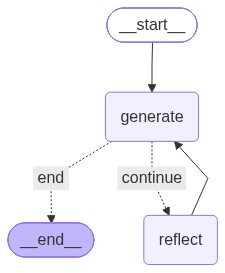

In [5]:
display(Image(reflection_graph.get_graph().draw_mermaid_png()))

In [6]:
task = "배송이 2주 지연된 고객에게 사과 이메일을 작성해줘. 고객명: 김민수, 주문번호: ORD-2024-1234"

result = reflection_graph.invoke(
    {"messages": [HumanMessage(content=task)], "iteration": 0}
)

print(f"총 반복 횟수: {result['iteration']}")
print(f"총 메시지 수: {len(result['messages'])}")
print("\n" + "=" * 60)

for msg in result["messages"]:
    print(f"\n[{msg.type}]")
    print(msg.text[:500])
    print("-" * 40)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


총 반복 횟수: 3
총 메시지 수: 6


[human]
배송이 2주 지연된 고객에게 사과 이메일을 작성해줘. 고객명: 김민수, 주문번호: ORD-2024-1234
----------------------------------------

[ai]
제목: [사과문] 배송 지연에 대해 진심으로 사과드립니다 (주문번호: ORD-2024-1234)

김민수 고객님, 안녕하십니까.

먼저 저희 제품을 믿고 주문해 주신 고객님께 심려를 끼쳐드려 진심으로 사과드립니다.

고객님께서 주문하신 상품(주문번호: ORD-2024-1234)의 배송이 예정보다 약 2주간 지연되었습니다. 오랜 시간 기쁜 마음으로 상품을 기다려 주셨을 고객님께 사전 안내조차 신속하게 드리지 못하고 불편을 드린 점, 머리 숙여 사과드립니다.

이번 지연은 최근 물류량 급증과 배송 시스템 점검 과정에서 발생한 차질로 인한 것이며, 이는 전적으로 저희의 준비 부족과 관리 소홀에서 비롯된 책임입니다.

현재 고객님의 주문건은 물류 센터에서 최우선 순위로 출고 작업을 완료하였습니다. 상품은 이번 주 내로 안전하게 도착할 예정이며, 상세한 배송 흐름을 확인하실 수 있도록 운송장 번호를 조만간 추가 안내해 드리겠습니다.

아울러, 오랜 기간 기다려 주신 죄송한 마음을 담아 고객님
----------------------------------------

[human]
- **배송 일정 및 운송장 번호 안내의 모호함**: '이번 주 내로', '조만간'이라는 표현은 이미 2주간 배송이 지연된 고객의 답답함을 해소하기에 부족합니다. 정확한 예상 수령일과 운송장 번호가 전달될 구체적인 시점(예: 금일 18시 이전 등)을 명시하는 방향으로 수정해 주세요.

- **보상(쿠폰) 관련 세부 정보 누락**: 10% 할인 쿠폰 지급 소식은 포함되어 있으나, 쿠폰의 유효기간이나 확인 방법에 대한 안내가 없어 추가 문의가 발생할 수 있습니다. 쿠폰 유효기간과 확인 경로(예: 마이페이지 > 쿠폰함)를 함께 기재하는 방향으로 보완해 주

반복할수록 피드백이 반영되어 품질이 올라가는 것을 확인할 수 있다. 하지만 Reflection에는 한계가 있다.

- 피드백이 **자연어**라서 "얼마나 좋아졌는지" 정량화할 수 없다
- "충분히 좋다"의 기준이 없으므로 항상 `max_iterations`까지 반복한다
- 반복할수록 피드백이 점점 미세해져 표현 수준의 차이만 지적할 수 있다. 이것이 실질적 개선인지는 별도로 판단해야 한다
- 반복이 많아지면 원래 의도에서 벗어나거나 과하게 수정되는 경우도 있다 (항상 품질이 올라가는 것은 아니다)

Evaluator-Optimizer 패턴은 루브릭과 합격 기준을 명시해 종료 시점과 개선 대상을 더 분명하게 만든다. 다만 평가자가 LLM이라면 점수의 주관성과 실행별 변동성은 여전히 남는다.

### Evaluator-Optimizer 패턴

Reflection과 구조는 비슷하지만 핵심 차이가 있다.

| | Reflection | Evaluator-Optimizer |
|---|---|---|
| 평가 결과 | 자유 형식의 자연어 피드백 | 항목별 점수와 근거를 구조화해 반환 |
| 종료 조건 | 주로 고정 횟수 | 합격 기준 달성 또는 최대 횟수 도달 |
| 개선 범위 | 전체적인 피드백 | 기준에 미달한 항목을 우선 개선 |
| 판정 특성 | 종료 판단이 명시적이지 않음 | 기준은 명시적이지만 LLM 점수는 달라질 수 있음 |

```
START → generate → evaluate → pass → END
          ↑            │ fail
          └── optimize ←┘
```

시나리오: 마케팅 카피 생성. 루브릭으로 평가하고, 미달 항목에 대한 수정 지시를 만든 뒤 다시 생성한다. 점수는 품질을 객관적으로 보장하는 값이 아니라 흐름을 제어하기 위한 구조화된 판단으로 사용한다.

### 루브릭 설계

루브릭(Rubric)은 **평가 항목과 점수 기준을 정리한 채점표**다. 좋은 루브릭은 구체적이고 측정 가능하다.

| 나쁜 루브릭 | 좋은 루브릭 |
|------------|------------|
| "매력적인가?" | "감정을 자극하는 단어가 1개 이상 포함되어 있는가?" |
| "적절한 길이인가?" | "50자 이상 150자 이하인가?" |
| "좋은 카피인가?" | "행동 유도(CTA)가 포함되어 있는가?" |

Pydantic 모델로 평가 결과를 구조화한다.

In [ ]:
class CriterionResult(BaseModel):
    score: int = Field(description="1~10 점수", ge=1, le=10)
    reason: str = Field(description="점수 근거 (1문장)")


class EvaluationResult(BaseModel):
    clarity: CriterionResult = Field(description="핵심 가치 전달 평가")
    emotion: CriterionResult = Field(description="타겟 공감과 변화 표현 평가")
    cta: CriterionResult = Field(description="행동 유도 평가")
    conciseness: CriterionResult = Field(description="길이와 중복 표현 평가")
    summary: str = Field(description="전체 평가 요약 (1~2문장)")

루브릭은 도메인마다 완전히 달라진다. 마케팅 카피라면 "감정 자극, CTA 포함, 글자 수", 기술 문서라면 "정확성, 재현 가능성, 코드 포함" 등이 핵심 기준이 된다. 설계할 때는 해당 도메인의 핵심 품질 기준을 먼저 정의하고, 각 기준을 측정 가능한 형태로 변환한 뒤, 점수 척도와 합격 기준을 설정한다.

In [ ]:
class EvalOptState(TypedDict):
    task: str
    copy: str
    evaluation: dict  # EvaluationResult를 dict로 저장
    iteration: int
    history: Annotated[list, add]  # 이전 카피, 평가 결과, 개선 지시 누적


MAX_ITERATIONS = 4
PASS_THRESHOLD = 8
EVALUATION_CRITERIA = ("clarity", "emotion", "cta", "conciseness")
evaluator_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)
evaluator = evaluator_llm.with_structured_output(EvaluationResult)

In [ ]:
def generate_copy(state: EvalOptState):
    """마케팅 카피를 생성한다. 이전 평가가 있으면 optimize 노드의 지시를 참고한다."""
    task = state["task"]
    history = state.get("history", [])

    if history:
        last = history[-1]
        prompt = (
            f"작업: {task}\n\n"
            f"이전 카피:\n{last['copy']}\n\n"
            f"개선 지시:\n{last['improvement']}\n\n"
            "위 지시를 반영해서 카피를 다시 작성해. 카피만 출력해."
        )
    else:
        prompt = f"다음 마케팅 카피를 작성해. 카피만 출력해.\n\n작업: {task}"

    response = generator_llm.invoke(prompt)
    return {"copy": response.text}


def evaluate_copy(state: EvalOptState):
    """루브릭에 따라 카피를 채점한다. Structured Output 사용."""
    copy = state["copy"]
    system = SystemMessage(content="""
너는 마케팅 카피 평가자다. 각 항목을 1~10점으로 평가하고 근거를 한 문장으로 작성하라.

평가 기준:
- clarity: 출퇴근 10분과 영어 실력 향상을 모두 명확히 전달하면 8점 이상
- emotion: 타겟이 공감할 문제나 기대할 변화를 구체적으로 표현하면 8점 이상
- cta: 독자가 즉시 실행할 수 있는 직접적인 행동 유도가 있으면 8점 이상
- conciseness: 공백 포함 50~150자이고 중복 표현이 없으면 8점 이상

기준을 충족하지 못한 항목에는 7점 이하를 부여하라.
""")
    result = evaluator.invoke([
        system,
        HumanMessage(content=f"<copy>\n{copy}\n</copy>"),
    ])

    evaluation = result.model_dump()
    evaluation["overall_pass"] = all(
        evaluation[name]["score"] >= PASS_THRESHOLD
        for name in EVALUATION_CRITERIA
    )

    return {
        "evaluation": evaluation,
        "iteration": state.get("iteration", 0) + 1,
    }


def optimize_copy(state: EvalOptState):
    """미달 항목의 평가 근거를 바탕으로 다음 생성에 사용할 수정 지시를 만든다."""
    evaluation = state["evaluation"]
    failed = [
        (name, evaluation[name])
        for name in EVALUATION_CRITERIA
        if evaluation[name]["score"] < PASS_THRESHOLD
    ]
    failed_items = [
        f"- {name} ({criterion['score']}점): {criterion['reason']}"
        for name, criterion in failed
    ]

    response = generator_llm.invoke(
        """너는 마케팅 카피 개선 편집자다. 평가 기준에 미달한 항목만 분석해
다음 생성 단계가 바로 적용할 수 있는 구체적인 수정 지시를 작성하라.
카피를 직접 다시 쓰지 말고, 유지할 내용과 바꿀 내용을 명확히 구분하라.
평가에 없는 새로운 제품 정보는 추가하지 마라.

<task>
""" + state["task"] + """
</task>

<current_copy>
""" + state["copy"] + """
</current_copy>

<failed_criteria>
""" + "\n".join(failed_items) + """
</failed_criteria>"""
    )

    return {
        "history": [{
            "copy": state["copy"],
            "evaluation": evaluation,
            "improvement": response.text,
        }],
    }


def should_continue_eval(state: EvalOptState):
    if state["evaluation"]["overall_pass"]:
        return "end"
    if state["iteration"] >= MAX_ITERATIONS:
        return "end"  # 상한 도달 시에도 종료
    return "fail"

In [ ]:
builder = StateGraph(EvalOptState)

builder.add_node("generate", generate_copy)
builder.add_node("evaluate", evaluate_copy)
builder.add_node("optimize", optimize_copy)

builder.add_edge(START, "generate")
builder.add_edge("generate", "evaluate")
builder.add_conditional_edges(
    "evaluate",
    should_continue_eval,
    {"end": END, "fail": "optimize"},
)
builder.add_edge("optimize", "generate")

eval_opt_graph = builder.compile()

In [ ]:
display(Image(eval_opt_graph.get_graph().draw_mermaid_png()))

In [ ]:
task = "AI 기반 영어 학습 앱 'SmartLingo' 출시 광고 카피. 타겟: 20~30대 직장인. 핵심 가치: 출퇴근 10분으로 영어 실력 향상."

for event in eval_opt_graph.stream({"task": task, "iteration": 0, "history": []}):
    node_name = list(event.keys())[0]
    state_update = event[node_name]

    if node_name == "generate":
        print(f"\n{'=' * 60}")
        print(f"[generate] 카피 생성")
        print(state_update["copy"])

    elif node_name == "evaluate":
        iteration = state_update["iteration"]
        evaluation = state_update["evaluation"]
        status = "PASS ✓" if evaluation["overall_pass"] else "FAIL ✗"
        print(f"\n[evaluate] 반복 {iteration} — {status}")
        for name in EVALUATION_CRITERIA:
            criterion = evaluation[name]
            mark = "PASS" if criterion["score"] >= PASS_THRESHOLD else "FAIL"
            print(f"  {name}: {criterion['score']}/10 ({mark}) - {criterion['reason']}")

    elif node_name == "optimize":
        h = state_update["history"][0]
        print(f"\n[optimize] 개선 지시")
        print(h["improvement"])

주의: 이 예제에서는 같은 LLM이 생성과 평가를 모두 수행한다. 합격 규칙을 코드로 고정해도 LLM이 매기는 점수는 실행마다 달라질 수 있다. 실무에서는 평가에 더 강한 모델을 쓰거나, 생성 모델과 별도의 모델을 사용해서 자기 평가 편향(self-evaluation bias)을 줄이기도 한다.

### 실습: 제품 리뷰 요약

아래 제품 리뷰를 한 문단(3~5문장)으로 요약하는 과제를 두 가지 패턴으로 구현한다.

- **Reflection**: generate → should_continue → reflect 루프
- **Evaluator-Optimizer**: generate → evaluate → optimize 루프

실무에서 Evaluator-Optimizer를 쓸 때 **루브릭 설계가 가장 중요한 단계**다. 루브릭이 모호하면 점수가 들쭉날쭉해서 Reflection과 다를 바 없고, 루브릭이 구체적이면 개선 방향이 명확해진다.

### 샘플 리뷰 데이터

In [10]:
REVIEW = """\
[무선 블루투스 이어폰 - StarBuds Pro 리뷰]

저는 이 이어폰을 출퇴근용으로 3개월째 사용하고 있습니다. 먼저 음질은 가격대비 정말 \
훌륭합니다. 저음이 풍부하고 고음도 깨끗하게 들립니다. 특히 팟캐스트를 들을 때 목소리가 \
또렷하게 들려서 좋습니다.

노이즈 캔슬링은 지하철에서 테스트해봤는데, 완전 차단까지는 아니지만 주변 소음을 \
70~80% 정도 줄여줍니다. 출퇴근 시 음악 감상에는 충분합니다. 다만 바람이 부는 야외에서는 \
노캔 성능이 많이 떨어집니다.

배터리는 공식 스펙이 7시간인데 실사용 5시간 반 정도 갑니다. 노캔 켜면 4시간 정도로 \
줄어듭니다. 케이스 충전 포함하면 총 20시간 정도 사용 가능합니다.

착용감은 제 귀에는 잘 맞는데, 귀가 작은 아내는 30분만 끼면 아프다고 합니다. 이어팁이 \
3종류 들어있긴 한데 가장 작은 것도 좀 큰 편입니다.

통화 품질은 솔직히 별로입니다. 상대방이 제 목소리가 멀리서 들린다고 합니다. \
조용한 실내에서는 괜찮은데 밖에서는 통화하기 어렵습니다.

앱 연동은 EQ 조절이 가능하고 노캔 강도도 조절할 수 있어서 편리합니다. \
다만 앱이 가끔 블루투스 연결이 끊기는 버그가 있습니다.

총평: 7만원대에 이 정도면 가성비 좋습니다. 통화보다 음악 감상 위주로 쓸 분께 추천합니다. \
통화를 많이 하시는 분은 다른 제품을 알아보시는 게 좋을 것 같습니다.
"""

print(REVIEW)

[무선 블루투스 이어폰 - StarBuds Pro 리뷰]

저는 이 이어폰을 출퇴근용으로 3개월째 사용하고 있습니다. 먼저 음질은 가격대비 정말 훌륭합니다. 저음이 풍부하고 고음도 깨끗하게 들립니다. 특히 팟캐스트를 들을 때 목소리가 또렷하게 들려서 좋습니다.

노이즈 캔슬링은 지하철에서 테스트해봤는데, 완전 차단까지는 아니지만 주변 소음을 70~80% 정도 줄여줍니다. 출퇴근 시 음악 감상에는 충분합니다. 다만 바람이 부는 야외에서는 노캔 성능이 많이 떨어집니다.

배터리는 공식 스펙이 7시간인데 실사용 5시간 반 정도 갑니다. 노캔 켜면 4시간 정도로 줄어듭니다. 케이스 충전 포함하면 총 20시간 정도 사용 가능합니다.

착용감은 제 귀에는 잘 맞는데, 귀가 작은 아내는 30분만 끼면 아프다고 합니다. 이어팁이 3종류 들어있긴 한데 가장 작은 것도 좀 큰 편입니다.

통화 품질은 솔직히 별로입니다. 상대방이 제 목소리가 멀리서 들린다고 합니다. 조용한 실내에서는 괜찮은데 밖에서는 통화하기 어렵습니다.

앱 연동은 EQ 조절이 가능하고 노캔 강도도 조절할 수 있어서 편리합니다. 다만 앱이 가끔 블루투스 연결이 끊기는 버그가 있습니다.

총평: 7만원대에 이 정도면 가성비 좋습니다. 통화보다 음악 감상 위주로 쓸 분께 추천합니다. 통화를 많이 하시는 분은 다른 제품을 알아보시는 게 좋을 것 같습니다.



### Reflection으로 리뷰 요약

위에서 배운 Reflection 패턴을 사용해서 리뷰를 한 문단(3~5문장)으로 요약하는 그래프를 구현하라. 장점, 단점, 추천 대상을 균형 있게 포함하고, 반복적인 검토를 통해 요약을 개선한다.

In [12]:
## 한번 더 연습 -> 이번에는 messages에 한번에 저장해보자
class ReflectionState(TypedDict):
    messages: Annotated[list, add_messages]
    iteration: int

MAX_ITERATIONS = 3
generator_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)
reviewer_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

In [13]:
def generate(state: ReflectionState):
    """초안을 작성하거나 피드백을 반영해 수정한다."""
    system = SystemMessage(content="""
너는 제품 리뷰 작성 전문가다.

사용자의 요청에 맞는 제품 리뷰를 작성하라. 대화에 리뷰 피드백이 있으면 빠짐없이 반영하되,
피드백이나 수정 과정을 언급하지 말고 자연스럽게 완성된 제품 리뷰로 작성하라.

작성 원칙:
- 한문단으로 작성한다.
- 3~5문장으로 작성한다.
- 장점, 단점, 추천 대상을 포함한다.
- 제품 리뷰에 없는 내용을 작성하지 않는다.

출력 형식:
- 한문단이라도 1문장마다 줄바꿈을 한다.
- 원본과 관련없는 내용은 출력하지 않는ㄷ.
""")
    # 전체 messages를 넘기면 generate는 이전 피드백까지 자연스럽게 참고한다
    response = generator_llm.invoke([system, *state["messages"]])
    return {
        "messages": [AIMessage(content=response.text)],
        "iteration": state.get("iteration", 0) + 1,
    }


def reflect(state: ReflectionState):
    """초안을 검토하고 구체적인 피드백을 준다."""
    system = SystemMessage(content="""
너는 제품 리뷰 편집자다. 주어진 초안을 검토하고 다음 수정에 바로 사용할 수 있는
구체적인 피드백을 작성하라. 

검토 기준:
- 한문단으로 출력하는가?
- 3~5문장으로 출력하는가?
- 장점, 단점, 추천 대상을 포함하는가?
- 본문에 없는 내용이 추가되지 않았는가?
- 간결한가?

출력 형식:
- 개선이 필요한 항목만 불릿 목록으로 작성한다.
- 각 항목에는 문제점과 수정 방향을 함께 적는다.
- 칭찬, 총평, 점수는 출력하지 않는다.
""")
    # 첫 메시지는 원래 요청이고, reflect는 generate 직후 실행되므로 마지막 메시지는 최신 초안이다
    original_request = state["messages"][0]
    latest_draft = state["messages"][-1]
    response = reviewer_llm.invoke([
        system,
        HumanMessage(content=(
            f"<request>\n{original_request.text}\n</request>\n\n"
            f"<draft>\n{latest_draft.text}\n</draft>"
        )),
    ])
    # HumanMessage로 넣는 이유: generate 노드의 LLM 입장에서 피드백은
    # "사용자 지시"처럼 작용해야 하므로 AIMessage가 아닌 HumanMessage로 넣는다
    return {
        "messages": [HumanMessage(content=response.text)],
    }


def should_continue(state: ReflectionState):
    if state["iteration"] >= MAX_ITERATIONS:
        return "end"
    return "continue"

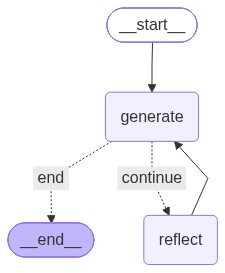

In [14]:
builder = StateGraph(ReflectionState)

builder.add_node("generate", generate)
builder.add_node("reflect", reflect)

builder.add_edge(START, "generate")
builder.add_conditional_edges(
    "generate",
    should_continue,
    {"continue": "reflect", "end": END},
)
builder.add_edge("reflect", "generate")

reflection_graph = builder.compile()
display(Image(reflection_graph.get_graph().draw_mermaid_png()))

In [15]:
result = reflection_graph.invoke(
    {"messages": [HumanMessage(content=REVIEW)], "iteration": 0}
)

print(f"총 반복 횟수: {result['iteration']}")
print(f"총 메시지 수: {len(result['messages'])}")
print("\n" + "=" * 60)

for msg in result["messages"]:
    print(f"\n[{msg.type}]")
    print(msg.text[:500])
    print("-" * 40)

총 반복 횟수: 3
총 메시지 수: 6


[human]
[무선 블루투스 이어폰 - StarBuds Pro 리뷰]

저는 이 이어폰을 출퇴근용으로 3개월째 사용하고 있습니다. 먼저 음질은 가격대비 정말 훌륭합니다. 저음이 풍부하고 고음도 깨끗하게 들립니다. 특히 팟캐스트를 들을 때 목소리가 또렷하게 들려서 좋습니다.

노이즈 캔슬링은 지하철에서 테스트해봤는데, 완전 차단까지는 아니지만 주변 소음을 70~80% 정도 줄여줍니다. 출퇴근 시 음악 감상에는 충분합니다. 다만 바람이 부는 야외에서는 노캔 성능이 많이 떨어집니다.

배터리는 공식 스펙이 7시간인데 실사용 5시간 반 정도 갑니다. 노캔 켜면 4시간 정도로 줄어듭니다. 케이스 충전 포함하면 총 20시간 정도 사용 가능합니다.

착용감은 제 귀에는 잘 맞는데, 귀가 작은 아내는 30분만 끼면 아프다고 합니다. 이어팁이 3종류 들어있긴 한데 가장 작은 것도 좀 큰 편입니다.

통화 품질은 솔직히 별로입니다. 상대방이 제 목소리가 멀리서 들린다고 합니다. 조용한 실내에서는 괜찮은데 밖에서는
----------------------------------------

[ai]
StarBuds Pro는 7만 원대의 뛰어난 가성비를 자랑하며, 풍부한 저음과 또렷한 목소리 전달력, 지하철 소음을 70~80% 줄여주는 만족스러운 노이즈 캔슬링 성능을 제공합니다.
전용 앱으로 EQ와 노이즈 캔슬링 강도를 편리하게 조절할 수 있어 출퇴근길 음악과 팟캐스트 감상에 유용합니다.
다만 야외 통화 품질이 떨이지고 제일 작은 이어팁도 커서 귀가 작은 사람은 통증을 느낄 수 있으며, 바람 부는 야외에서 노캔 성능이 떨어지는 단점이 있습니다.
따라서 통화를 많이 하시는 분보다는 출퇴근길에 통화보다 음악 감상을 위주로 하시는 분들에게 가성비 제품으로 추천합니다.
----------------------------------------

[human]
* **문단 형식 미준수**: 현재 초안이 줄바꿈을 통해 4개의 문단으로 나누어져 있습니다

In [20]:
# 완성한 그래프를 review_reflection_graph에 저장하세요.
# 1. 제품 리뷰를 입력한다.
# 2. 리뷰를 3~5문장으로 요약한다
# 3. 현재 반복횟수를 확인하여 진행 
# 4. 최신 요약 검토 
# 5. 검토 결과 피드백 메시지 작성
# 6. 피드백을 반영 요약을 수정
# 7. 최종 요약 반환

# - state
#  : 리뷰, 요약, 피드백, 반복 횟수,    # 최종 결과는 그냥 출력하면된다

class ReflectionState(TypedDict):
    review: str
    summary: str
    feedback: str
    iteration: int


MAX_ITERATIONS = 3
generator_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)
reviewer_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

In [21]:
def generate(state: ReflectionState):
    """초안을 작성하거나 피드백을 반영해 수정한다."""
    system = SystemMessage(content="""
너는 제품 리뷰 요약 전문가다.

제품의 리뷰의 장점, 단점, 추천 대상을 균형 있게 포함해.
원문에 없는 내용은 추가하지 않는다.

작성 원칙:
- 명확하게 장점과 단점을 구분한다.
- 불필요한 말을 하지 않는다.

출력 형식:
- 한 문단으로 작성한다
- 2문장으로 작성한다.
- 요약문만 작성하고 출력한다.
""")
    # 전체 messages를 넘기면 generate는 이전 피드백까지 자연스럽게 참고한다
    response = generator_llm.invoke([
        system,
        HumanMessage(content=(
        f"<review>\n{state['review']}\n</review>\n\n"
        f"<summary>\n{state.get('summary', '')}\n</summary>\n\n"
        f"<feedback>\n{state.get('feedback', '')}\n</feedback>"
        ))])
    return {
        "summary": response.text,
        "iteration": state.get("iteration", 0) + 1,
    }


def reflect(state: ReflectionState):
    """초안을 검토하고 구체적인 피드백을 준다."""
    system = SystemMessage(content="""
너는 제품 리뷰 요약 편집자다. 주어진 초안을 검토하고 다음 수정에 바로 사용할 수 있는
구체적인 피드백을 작성하라.

검토 기준:
- 장점이 드러나는가?
- 단점이 드러나는가?
- 추천 대상이 드러나는가?
- 한문단(2문장)인가?
- 원문에 없는 내용을 추가하지 않았는가?

출력 형식:
- 개선이 필요한 항목만 불릿 목록으로 작성한다.
- 각 항목에는 문제점과 수정 방향을 함께 적는다.
""")
    # 첫 메시지는 원래 요청이고, reflect는 generate 직후 실행되므로 마지막 메시지는 최신 초안이다
    original_request = state["review"]
    latest_draft = state["summary"]
    response = reviewer_llm.invoke([
        system,
        HumanMessage(content=(
            f"<review>\n{original_request}\n</review>\n\n"
            f"<summary>\n{latest_draft}\n</summary>"
        )),
    ])
    # HumanMessage로 넣는 이유: generate 노드의 LLM 입장에서 피드백은
    # "사용자 지시"처럼 작용해야 하므로 AIMessage가 아닌 HumanMessage로 넣는다
    return {
        "feedback": response.text,
    }


def should_continue(state: ReflectionState):
    if state["iteration"] >= MAX_ITERATIONS:
        return "end"
    return "continue"

In [22]:
builder = StateGraph(ReflectionState)

builder.add_node("generate", generate)
builder.add_node("reflect", reflect)

builder.add_edge(START, "generate")
builder.add_conditional_edges(
    "generate",
    should_continue,
    {"continue": "reflect", "end": END},
)
builder.add_edge("reflect", "generate")

reflection_graph = builder.compile()

In [24]:
result = reflection_graph.invoke(
    {"review": REVIEW, "iteration": 0}
)

print(f"총 반복 횟수: {result['iteration']}")
print(f"총 요약 글자 수: {len(result['summary'])}")
print("\n" + "=" * 60)

print(result["summary"])

총 반복 횟수: 3
총 요약 글자 수: 178

StarBuds Pro는 뛰어난 가성비 음질과 효과적인 노이즈 캔슬링, 편리한 앱 연동이 장점이지만, 아쉬운 통화 품질과 바람 부는 환경에서의 노캔 성능 저하, 귀가 작은 사용자에게 느껴지는 착용 통증이 단점입니다. 따라서 통화를 많이 하는 분보다는 출퇴근길에 음악이나 팟캐스트 감상을 주로 하는 사용자에게 추천합니다.


### Evaluator-Optimizer로 리뷰 요약

같은 리뷰를 Evaluator-Optimizer 패턴으로 요약한다. 아래 루브릭은 구현을 돕기 위한 참고 예시이며, 그대로 사용할 필요는 없다. 필요에 따라 평가 항목과 기준을 수정하거나 추가한다. 모든 항목이 8점 이상이면 통과한다.

루브릭 (각 1~10점):
- completeness: 원문의 핵심 장점과 단점이 각각 1개 이상 포함되고, 가격 정보가 반영되었는가?
- accuracy: 가격, 사용 시간, 성능 등 제품 정보가 원문과 일치하며, 원문에 없는 정보를 추가하지 않았는가?
- conciseness: 핵심 정보의 불필요한 반복 없이 3~5문장으로 작성되었는가?
- recommendation: 적합한 사용자와 부적합한 사용자를 원문의 근거에 따라 모두 언급했는가?

In [16]:
## 한번 더 연습
class CriterionResult(BaseModel):
    score: int = Field(description="1~10 점수", ge=1, le=10)
    reason: str = Field(description="점수 근거 (1문장)")


class EvaluationResult(BaseModel):
    completeness: CriterionResult = Field(description="핵심 장점, 단점, 가격 정보 평가")
    accuracy: CriterionResult = Field(description="가격, 사용 시간, 성능 등 제품 정보가 원문과 일치하는지 평가")
    conciseness: CriterionResult = Field(description="핵심 정보의 불필요한 반복이 있는지 평가")
    recommendation: CriterionResult = Field(description="적합 사용자, 부적합 사용자를 근거에 따라 언급한 평가")
    summary: str = Field(description="전체 평가 요약 (1~2문장)")


In [17]:
class EvalOptState(TypedDict):
    review: str
    summary: str
    evaluation: dict  # EvaluationResult를 dict로 저장
    iteration: int
    history: Annotated[list, add]  


MAX_ITERATIONS = 4
PASS_THRESHOLD = 8
EVALUATION_CRITERIA = ("completeness", "accuracy", "conciseness", "recommendation")
evaluator_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)
evaluator = evaluator_llm.with_structured_output(EvaluationResult)

In [18]:
def generate_summary(state: EvalOptState):
    """제품 리뷰를 생성한다. 이전 평가가 있으면 optimize 노드의 지시를 참고한다."""
    review = state["review"]
    history = state.get("history", [])

    if history:
        last = history[-1]
        prompt = (
            f"작업: {review}\n\n"
            f"이전 리뷰:\n{last['summary']}\n\n"
            f"개선 지시:\n{last['improvement']}\n\n"
            "위 지시를 반영해서 리뷰를 다시 작성해. 리뷰만 출력해."
        )
    else:
        prompt = f"다음 제품 리뷰를 작성해. 리뷰만 출력해.\n\n작업: {review}"

    response = generator_llm.invoke(prompt)
    return {"summary": response.text}


def evaluate_summary(state: EvalOptState):
    """루브릭에 따라 제품 리뷰를 채점한다. Structured Output 사용."""
    summary = state["summary"]
    system = SystemMessage(content="""
너는 마케팅 카피 평가자다. 각 항목을 1~10점으로 평가하고 근거를 한 문장으로 작성하라.

평가 기준:
- completeness: 원문의 핵심 장점과 단점이 각각 1개 이상 포함되고, 가격 정보가 반영되었는가 8점?
- accuracy: 가격, 사용 시간, 성능 등 제품 정보가 원문과 일치하며, 원문에 없는 정보를 추가하지 않았는가 8점?
- conciseness: 핵심 정보의 불필요한 반복 없이 3~5문장으로 작성되었는가 8점?
- recommendation: 적합한 사용자와 부적합한 사용자를 원문의 근거에 따라 모두 언급했는가 8점?

기준을 충족하지 못한 항목에는 7점 이하를 부여하라.
""")
    result = evaluator.invoke([
        system,
        HumanMessage(content=f"<summary>\n{summary}\n</summary>"),
    ])

    evaluation = result.model_dump()
    evaluation["overall_pass"] = all(
        evaluation[name]["score"] >= PASS_THRESHOLD
        for name in EVALUATION_CRITERIA
    )

    return {
        "evaluation": evaluation,
        "iteration": state.get("iteration", 0) + 1,
    }


def optimize_summary(state: EvalOptState):
    """미달 항목의 평가 근거를 바탕으로 다음 생성에 사용할 수정 지시를 만든다."""
    evaluation = state["evaluation"]
    failed = [
        (name, evaluation[name])
        for name in EVALUATION_CRITERIA
        if evaluation[name]["score"] < PASS_THRESHOLD
    ]
    failed_items = [
        f"- {name} ({criterion['score']}점): {criterion['reason']}"
        for name, criterion in failed
    ]

    response = generator_llm.invoke(
        """너는 제품 리뷰 개선 편집자다. 평가 기준에 미달한 항목만 분석해
다음 생성 단계가 바로 적용할 수 있는 구체적인 수정 지시를 작성하라.
리뷰를 직접 다시 쓰지 말고, 유지할 내용과 바꿀 내용을 명확히 구분하라.
평가에 없는 정보는 추가하지 마라.

<review>
""" + state["review"] + """
</task>

<current_summary>
""" + state["summary"] + """
</current_summary>

<failed_criteria>
""" + "\n".join(failed_items) + """
</failed_criteria>"""
    )

    return {
        "history": [{
            "summary": state["summary"],
            "evaluation": evaluation,
            "improvement": response.text,
        }],
    }


def should_continue_eval(state: EvalOptState):
    if state["evaluation"]["overall_pass"]:
        return "end"
    if state["iteration"] >= MAX_ITERATIONS:
        return "end"  # 상한 도달 시에도 종료
    return "fail"

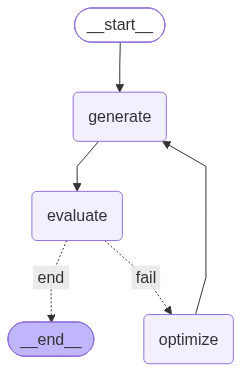

In [20]:
builder = StateGraph(EvalOptState)

builder.add_node("generate", generate_summary)
builder.add_node("evaluate", evaluate_summary)
builder.add_node("optimize", optimize_summary)

builder.add_edge(START, "generate")
builder.add_edge("generate", "evaluate")
builder.add_conditional_edges(
    "evaluate",
    should_continue_eval,
    {"end": END, "fail": "optimize"},
)
builder.add_edge("optimize", "generate")

eval_opt_graph = builder.compile()

display(Image(eval_opt_graph.get_graph().draw_mermaid_png()))

In [23]:
for event in eval_opt_graph.stream({"review": REVIEW, "iteration": 0, "history": []}):
    node_name = list(event.keys())[0]
    state_update = event[node_name]

    if node_name == "generate":
        print(f"\n{'=' * 60}")
        print(f"[generate] 요약 생성")
        print(state_update["summary"])

    elif node_name == "evaluate":
        iteration = state_update["iteration"]
        evaluation = state_update["evaluation"]
        status = "PASS ✓" if evaluation["overall_pass"] else "FAIL ✗"
        print(f"\n[evaluate] 반복 {iteration} — {status}")
        for name in EVALUATION_CRITERIA:
            criterion = evaluation[name]
            mark = "PASS" if criterion["score"] >= PASS_THRESHOLD else "FAIL"
            print(f"  {name}: {criterion['score']}/10 ({mark}) - {criterion['reason']}")

    elif node_name == "optimize":
        h = state_update["history"][0]
        print(f"\n[optimize] 개선 지시")
        print(h["improvement"])


[generate] 요약 생성
**[무선 블루투스 이어폰 - StarBuds Pro 3개월 사용 후기]**

**1. 음질 (★★★★☆)**
가격 대비 음질이 정말 훌륭합니다. 저음이 풍부하고 고음도 깨끗하게 들리며, 특히 팟캐스트를 들을 때 목소리가 또렷하게 전달되어 만족스럽습니다.

**2. 노이즈 캔슬링 (★★★☆☆)**
지하철 출퇴근 시 주변 소음을 70~80% 정도 줄여주어 음악 감상용으로 충분합니다. 다만 완전 차단까지는 아니며, 바람이 부는 야외에서는 노캔 성능이 많이 떨어집니다.

**3. 배터리 (★★★☆☆)**
공식 스펙은 7시간이지만 실사용 시 약 5시간 반 정도 작동합니다. 노이즈 캔슬링을 켜면 4시간 정도로 줄어들며, 케이스 충전 포함 시 총 20시간 정도 사용할 수 있습니다.

**4. 착용감 (★★★☆☆)**
일반적인 귀에는 잘 맞지만 귀가 작은 분에게는 불편할 수 있습니다. 동봉된 3종류의 이어팁 중 가장 작은 것도 다소 큰 편이라 귀가 작은 사람 기준 30분 정도 착용 시 통증이 발생했습니다.

**5. 통화 품질 (★★☆☆☆)**
아쉬운 부분입니다. 조용한 실내에서는 괜찮지만 야외에서는 상대방이 목소리가 멀리서 들린다고 하여 통화하기 어렵습니다.

**6. 앱 연동 (★★★☆☆)**
EQ 조절과 노이즈 캔슬링 강도 조절이 가능해 편리합니다. 다만 간혹 앱에서 블루투스 연결이 끊기는 버그가 있습니다.

**[총평]**
7만 원대에 이 정도 성능이면 가성비가 매우 뛰어납니다. 통화보다는 **음악 감상 위주로 사용할 출퇴근용 이어폰**을 찾는 분께 추천합니다. 통화 비중이 높은 분은 다른 제품을 고려하시는 것이 좋습니다.

[evaluate] 반복 1 — FAIL ✗
  completeness: 9/10 (PASS) - 7만 원대의 가격 정보와 함께 우수한 음질이라는 장점 및 아쉬운 통화 품질이라는 단점이 모두 명확히 포함되어 있습니다.
  accuracy: 10/10 (PASS) - 가격, 배터리 사용 시간, 기능 등 제품에 대한

In [27]:
# 완성한 그래프를 review_eval_opt_graph에 저장하세요.
# 최종 요약은 summary, 평가 결과는 evaluation에 저장하세요.

# 흐름
# 리뷰 입력 -> 요약 -> 평가 -> 통과시 종료
#              ^   
#             ㅣ   <--- 미통과시 다시 요약
#  필요한 state : review, summary, evaluation, feedback, interation, history

class CriterionResult(BaseModel):
    score: int = Field(description="1~10 점수", ge=1, le=10)
    reason: str = Field(description="점수 근거 (1문장)")


class EvaluationResult(BaseModel):
    completeness: CriterionResult = Field(description="원문의 핵심 장점과 단점이 각각 1개 이상 포함되고, 가격 정보가 반영되었는가?")
    accuracy: CriterionResult = Field(description="가격, 사용 시간, 성능 등 제품 정보가 원문과 일치하며, 원문에 없는 정보를 추가하지 않았는가?")
    conciseness: CriterionResult = Field(description="핵심 정보의 불필요한 반복 없이 3~5문장으로 작성되었는가?")
    recommendation: CriterionResult = Field(description="적합한 사용자와 부적합한 사용자를 원문의 근거에 따라 모두 언급했는가?")
    summary: str = Field(description="전체 평가 요약 (1~2문장)")

In [28]:
class EvalOptState(TypedDict):
    review: str
    summary: str
    evaluation: dict  # EvaluationResult를 dict로 저장
    feedback: str
    iteration: int
    history: Annotated[list, add]  


MAX_ITERATIONS = 4
PASS_THRESHOLD = 8
EVALUATION_CRITERIA = ("completeness", "accuracy", "conciseness", "recommendation")
evaluator_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)
evaluator = evaluator_llm.with_structured_output(EvaluationResult)

In [29]:
def generate_summary(state: EvalOptState):
    """제품의 요약 리뷰를 생성한다. 이전 피드백이 있으면 참고한다."""
    review = state["review"]
    summary = state.get("summary", "")
    feedback = state.get("feedback", "")
    

    if feedback:
        prompt = (
            f"제품 리뷰:\n{review}\n\n"
            f"이전 요약:\n{summary}\n\n"
            f"개선 지시:\n{feedback}\n\n"
            "위 개선 지시를 반영하여 제품 리뷰를 3~5문장 한 문단으로 다시 요약해. "
            "장점, 단점, 추천 대상을 포함하고 원문에 없는 내용은 추가하지 마."            
        )
    else:
        prompt = (
            f"다음 제품 리뷰를 3~5문장 한 문단으로 요약해"
            f"장점, 단점, 추천 대상을 포함하고 원문에 없는 내용은 추가하지마. \n\n"
            f"제품 리뷰 : \n{review}"
        )

    response = generator_llm.invoke(prompt)
    return {"summary": response.text}


def evaluate_summary(state: EvalOptState):
    """루브릭에 따라 summary를 채점한다. Structured Output 사용."""
    summary = state["summary"]
    review = state["review"]

    system = SystemMessage(content="""
너는 제품 요약 평가자다. 각 항목을 1~10점으로 평가하고 근거를 한 문장으로 작성하라.

평가 기준:
- completeness: 원문의 핵심 장점과 단점이 각각 1개 이상 포함되고, 가격 정보가 반영되었으면 8점
- accuracy: 가격, 사용 시간, 성능 등 제품 정보가 원문과 일치하면 8점
- conciseness: 핵심 정보의 불필요한 반복 없이 3~5문장으로 작성되었으면 8점
- recommendation: 적합한 사용자와 부적합한 사용자를 원문의 근거에 따라 모두 언급했으면 8점

기준을 충족하지 못한 항목에는 7점 이하를 부여하라.
""")
    result = evaluator.invoke([
        system,
        HumanMessage(content=(
            f"<summary>\n{summary}\n</summary>"
            f"<review>\n{review}\n</review>"
            )),
    ])

    evaluation = result.model_dump()
    evaluation["overall_pass"] = all(
        evaluation[name]["score"] >= PASS_THRESHOLD
        for name in EVALUATION_CRITERIA
    )

    return {
        "evaluation": evaluation,
        "iteration": state.get("iteration", 0) + 1,
    }


def optimize_summary(state: EvalOptState):
    """미달 항목의 평가 근거를 바탕으로 다음 생성에 사용할 수정 지시를 만든다."""
    evaluation = state["evaluation"]
    failed = [
        (name, evaluation[name])
        for name in EVALUATION_CRITERIA
        if evaluation[name]["score"] < PASS_THRESHOLD
    ]
    failed_items = [
        f"- {name} ({criterion['score']}점): {criterion['reason']}"
        for name, criterion in failed
    ]

    response = generator_llm.invoke(
        """너는 제품 리뷰 개선 편집자다. 평가 기준에 미달한 항목만 분석해
다음 생성 단계가 바로 적용할 수 있는 구체적인 수정 지시를 작성하라.
요약을 직접 다시 쓰지 말고, 유지할 내용과 바꿀 내용을 명확히 구분하라.
평가에 없는 새로운 제품 정보는 추가하지 마라.

<summary>
""" + state["summary"] + """
</summary>

<current_review>
""" + state["review"] + """
</current_review>

<failed_criteria>
""" + "\n".join(failed_items) + """
</failed_criteria>"""
    )

    return {
        "feedback": response.text,
        "history": [{
            "summary": state["summary"],
            "evaluation": evaluation,
            "feedback": response.text,
        }],
    }


def should_continue_eval(state: EvalOptState):
    if state["evaluation"]["overall_pass"]:
        return "end"
    if state["iteration"] >= MAX_ITERATIONS:
        return "end"  # 상한 도달 시에도 종료
    return "fail"

In [30]:
builder = StateGraph(EvalOptState)

builder.add_node("generate", generate_summary)
builder.add_node("evaluate", evaluate_summary)
builder.add_node("optimize", optimize_summary)

builder.add_edge(START, "generate")
builder.add_edge("generate", "evaluate")
builder.add_conditional_edges(
    "evaluate",
    should_continue_eval,
    {"end": END, "fail": "optimize"},
)
builder.add_edge("optimize", "generate")

eval_opt_graph = builder.compile()

In [31]:

for event in eval_opt_graph.stream({"review": REVIEW, "iteration": 0}):
    node_name = list(event.keys())[0]
    state_update = event[node_name]

    if node_name == "generate":
        print(f"\n{'=' * 60}")
        print(f"[generate] 요약 생성")
        print(state_update["summary"])

    elif node_name == "evaluate":
        iteration = state_update["iteration"]
        evaluation = state_update["evaluation"]
        status = "PASS ✓" if evaluation["overall_pass"] else "FAIL ✗"
        print(f"\n[evaluate] 반복 {iteration} — {status}")
        for name in EVALUATION_CRITERIA:
            criterion = evaluation[name]
            mark = "PASS" if criterion["score"] >= PASS_THRESHOLD else "FAIL"
            print(f"  {name}: {criterion['score']}/10 ({mark}) - {criterion['reason']}")

    elif node_name == "optimize":
        h = state_update["history"][0]
        print(f"\n[optimize] 개선 지시")
        print(h["feedback"])


[generate] 요약 생성
StarBuds Pro는 7만 원대의 뛰어난 가성비를 바탕으로 가격 대비 훌륭한 음질, 실내 및 지하철에서의 양호한 노이즈 캔슬링 성능, 편리한 전용 앱 기능을 장점으로 갖추고 있습니다. 반면 바람 부는 야외에서의 노이즈 캔슬링 성능 저하, 실사용 배터리 타임의 아쉬움, 귀가 작은 사용자에게 느껴지는 통증, 아쉬운 야외 통화 품질과 앱 연결 오류는 단점으로 지목됩니다. 따라서 이 제품은 통화 기능보다 가성비 좋은 음악 감상용 이어폰을 찾는 분에게 추천합니다.

[evaluate] 반복 1 — FAIL ✗
  completeness: 8/10 (PASS) - 원문의 주요 장단점과 7만 원대라는 가격 정보가 빠짐없이 포함되어 있습니다.
  accuracy: 8/10 (PASS) - 가격, 성능, 노이즈 캔슬링 및 통화 품질 등 모든 제품 정보가 원문 내용과 정확하게 일치합니다.
  conciseness: 8/10 (PASS) - 불필요한 정보 반복 없이 핵심 내용을 담아 3문장으로 간결하게 작성되었습니다.
  recommendation: 7/10 (FAIL) - 적합한 사용자는 명시되었으나 통화를 자주 하는 부적합 사용자에 대한 직접적인 언급이 부족합니다.

[optimize] 개선 지시
평가 기준에 미달한 항목(**recommendation**)을 개선하기 위한 수정 지시서입니다. 다음 생성 단계에서 아래 지침을 그대로 적용하여 수정해 주시기 바랍니다.

---

### [평가 미달 항목 분석]
* **미달 항목:** recommendation (추천/비추천 대상 명시)
* **분석:** 리뷰 마지막 [총평] 부분에 적합한 사용자(음악 감상 위주)는 명시되어 있으나, 부적합한 사용자(통화를 자주 하는 사용자)에 대한 비추천 메시지가 다소 완곡하여 명확성이 부족합니다. 부적합 대상에 대한 경고/대조를 더 직접적이고 명확하게 전달해야 합니다.

---

### [수정 지시사항]

#### 1. 대상 위치
* 리뷰의 맨 마지막 문단인 